# Decision Tree — Feature Engineered

Two types of features are added on top of the base standardized set:

- **Absolute values** `|X|` for every numeric feature — captures *extremeness* regardless of direction, directly exploiting the observation that Problem SKU has wider distributions
- **Pairwise products** of the top 5 features by DT importance — amplifies cases where multiple features are simultaneously anomalous

A full hyperparameter sweep (class weight × max depth × min leaf size) is run on the engineered feature set and results are plotted across all configurations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, precision_recall_curve,
)

path = r"..\Data\SyntheticData\2026_03_31_01_52_14\std_synthetic_data_2026_03_31_01_52_14.csv"
df   = pd.read_csv(path)
target = "Problem_SKU"
seed   = 1337

numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]

size_dummies     = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)
defect_linked    = df['Defect_In_Linked_Receive'].astype(int)

X_base = pd.concat([df[numeric_features], size_dummies, defect_linked], axis=1)
y      = df[target]

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=seed, stratify=y
)

print(f"Train: {X_train_base.shape}  Test: {X_test_base.shape}")
print(f"Base rate: {y_test.mean():.3f}")

Train: (220000, 13)  Test: (55000, 13)
Base rate: 0.074


In [2]:
# ── Feature engineering ──────────────────────────────────────────────────────
# Top 5 by DT feature importance (from decision_tree.ipynb results)
top5 = [
    "#_Picks_In_Clique_std",
    "Aisle_Hold_%_std",
    "Current_Max_Volume_std",
    "#_Picks_std",
    "ABS_Volume_Difference_std",
]
short = {
    "#_Picks_In_Clique_std":   "picks_clique",
    "Aisle_Hold_%_std":        "aisle",
    "Current_Max_Volume_std":  "max_vol",
    "#_Picks_std":             "picks",
    "ABS_Volume_Difference_std": "abs_vol",
}

def engineer_features(X):
    Xe = X.copy()
    # 1. Absolute values of all standardised numeric features
    #    Captures *extremeness* regardless of direction — Problem_SKU=True
    #    has wider distributions, so |z| is a better separability signal.
    for col in numeric_features:
        Xe[f"|{col}|"] = X[col].abs()
    # 2. Pairwise products of absolute values of top-5 features: |A| × |B|
    #    Raw products A×B have two problems with z-scored data:
    #      (a) Sign ambiguity: neg×neg = pos, indistinguishable from pos×pos,
    #          so the tree cannot tell "both anomalously low" from "both high."
    #      (b) Near-zero suppression: a near-mean value (e.g. 0.3) collapses
    #          the product of a genuine outlier (e.g. 3.0 × 0.3 = 0.9 ≈ noise).
    #    |A|×|B| grows monotonically when both features are simultaneously
    #    extreme and stays small when either is near its mean — exactly the
    #    co-anomaly signal we want.
    for f1, f2 in combinations(top5, 2):
        Xe[f"|{short[f1]}| x |{short[f2]}|"] = X[f1].abs() * X[f2].abs()
    return Xe

X_train_eng = engineer_features(X_train_base)
X_test_eng  = engineer_features(X_test_base)

base_cols = list(X_base.columns)
abs_cols  = [f"|{c}|" for c in numeric_features]
prod_cols = [f"|{short[f1]}| x |{short[f2]}|" for f1, f2 in combinations(top5, 2)]
all_cols  = base_cols + abs_cols + prod_cols

print(f"Original features  : {len(base_cols)}")
print(f"Absolute values    : {len(abs_cols)}")
print(f"Pairwise |A|×|B|   : {len(prod_cols)}")
print(f"Total              : {len(all_cols)}")
print()
print("Engineered sample:")
print(X_train_eng[abs_cols[:3] + prod_cols[:3]].head(3))

Original features  : 13
Absolute values    : 9
Pairwise |A|×|B|   : 10
Total              : 32

Engineered sample:
        |Global_SKU_Defect_Rate_%_std|  |ABS_Volume_Difference_std|  \
170769                        1.119167                     0.054665   
250486                        1.012074                     1.237428   
117441                        0.070746                     0.947334   

        |Aisle_Hold_%_std|  |picks_clique| x |aisle|  \
170769            0.758457                  0.108161   
250486            0.490297                  0.225327   
117441            0.732311                  1.754443   

        |picks_clique| x |max_vol|  |picks_clique| x |picks|  
170769                    0.010545                  0.093468  
250486                    0.462273                  0.079408  
117441                    4.193017                  0.249843  


## Hyperparameter Sweep

Every combination of class weight × max depth × min samples per leaf is trained and evaluated. Results are collected into a single DataFrame for plotting.

In [3]:
class_weights = [None,
                 {False: 1, True: 3},
                 {False: 1, True: 5},
                 {False: 1, True: 7},
                 {False: 1, True: 10},
                 'balanced']
weight_labels = ['none', '3x', '5x', '7x', '10x', 'balanced']
max_depths    = [5, 8, 12, None]
min_leaves    = [20, 50, 100]

records = []
for cw, cw_lbl in zip(class_weights, weight_labels):
    for md in max_depths:
        for ml in min_leaves:
            dt = DecisionTreeClassifier(
                class_weight=cw, max_depth=md,
                min_samples_leaf=ml, random_state=seed
            )
            dt.fit(X_train_eng, y_train)
            y_pred  = dt.predict(X_test_eng)
            y_proba = dt.predict_proba(X_test_eng)[:, 1]
            records.append({
                'weight':    cw_lbl,
                'max_depth': 'None' if md is None else str(md),
                'min_leaf':  ml,
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'recall':    recall_score(y_test, y_pred, zero_division=0),
                'f1':        f1_score(y_test, y_pred, zero_division=0),
                'auc':       roc_auc_score(y_test, y_proba),
                '_model':    dt,
                '_proba':    y_proba,
            })

sweep_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                          for r in records])

print(f"Models trained: {len(records)}")
print("\nTop 10 by F1:")
print(sweep_df.sort_values('f1', ascending=False).head(10).to_string(index=False))

Models trained: 72

Top 10 by F1:
weight max_depth  min_leaf  precision   recall       f1      auc
    5x         8        20   0.400529 0.523586 0.453864 0.845239
    5x         8        50   0.391203 0.540380 0.453848 0.846656
    5x         8       100   0.387414 0.544332 0.452660 0.847402
    3x         8       100   0.453743 0.444554 0.449102 0.845209
    3x         8        50   0.462001 0.436898 0.449099 0.844442
    3x        12       100   0.425856 0.470240 0.446948 0.844068
    3x      None       100   0.418881 0.478884 0.446877 0.822872
    3x         8        20   0.461457 0.430230 0.445297 0.843480
    3x        12        50   0.419248 0.468017 0.442292 0.837243
    5x        12       100   0.351620 0.576192 0.436728 0.840968


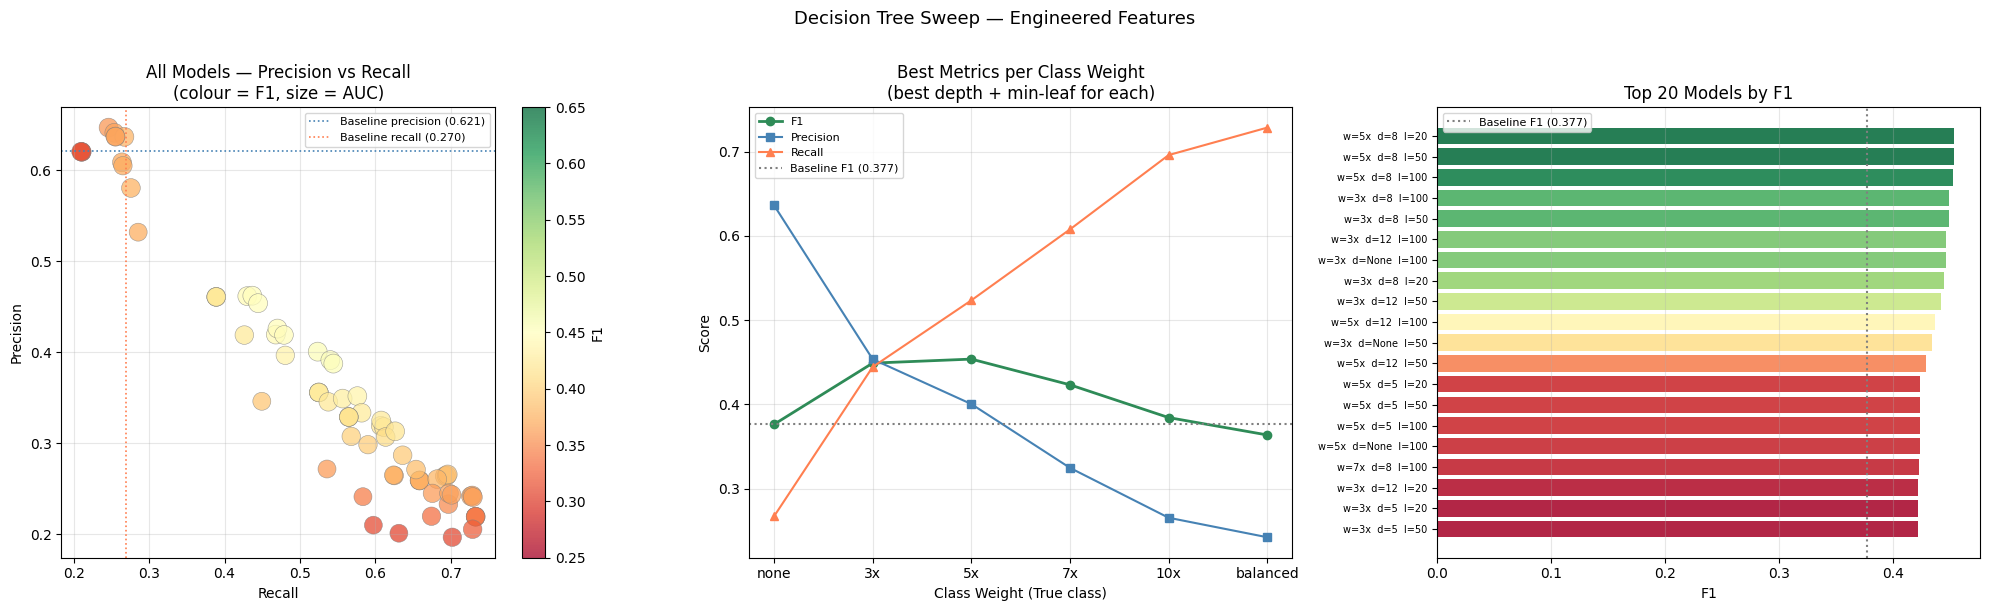

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 1. Scatter: all models, precision vs recall ───────────────────────────────
ax = axes[0]
sc = ax.scatter(
    sweep_df['recall'], sweep_df['precision'],
    c=sweep_df['f1'], cmap='RdYlGn', vmin=0.25, vmax=0.65,
    s=sweep_df['auc'] * 220, alpha=0.75,
    edgecolors='gray', linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label='F1')
ax.axhline(0.621, color='steelblue', linestyle=':', linewidth=1.2,
           label='Baseline precision (0.621)')
ax.axvline(0.270, color='coral',     linestyle=':', linewidth=1.2,
           label='Baseline recall (0.270)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('All Models — Precision vs Recall\n(colour = F1, size = AUC)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 2. Line: best F1 / precision / recall per class weight ────────────────────
ax2 = axes[1]
best_per_wt = (
    sweep_df.loc[sweep_df.groupby('weight')['f1'].idxmax()]
            .set_index('weight')
            .reindex(weight_labels)
)
ax2.plot(weight_labels, best_per_wt['f1'],        marker='o', linewidth=2,
         color='seagreen',  label='F1')
ax2.plot(weight_labels, best_per_wt['precision'], marker='s', linewidth=1.5,
         color='steelblue', label='Precision')
ax2.plot(weight_labels, best_per_wt['recall'],    marker='^', linewidth=1.5,
         color='coral',     label='Recall')
ax2.axhline(0.377, color='gray', linestyle=':', label='Baseline F1 (0.377)')
ax2.set_xlabel('Class Weight (True class)')
ax2.set_ylabel('Score')
ax2.set_title('Best Metrics per Class Weight\n(best depth + min-leaf for each)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── 3. Horizontal bar: top 20 models by F1 ───────────────────────────────────
ax3 = axes[2]
top20  = sweep_df.nlargest(20, 'f1').reset_index(drop=True)
labels = [f"w={r['weight']}  d={r['max_depth']}  l={r['min_leaf']}"
          for _, r in top20.iterrows()]
cmap   = plt.cm.RdYlGn
colors = [cmap(v) for v in (top20['f1'] - top20['f1'].min()) /
          (top20['f1'].max() - top20['f1'].min() + 1e-9)]
ax3.barh(range(len(top20)), top20['f1'], color=colors, alpha=0.85)
ax3.set_yticks(range(len(top20)))
ax3.set_yticklabels(labels, fontsize=7)
ax3.axvline(0.377, color='gray', linestyle=':', label='Baseline F1 (0.377)')
ax3.set_xlabel('F1')
ax3.set_title('Top 20 Models by F1')
ax3.legend(fontsize=8)
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

plt.suptitle('Decision Tree Sweep — Engineered Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Best Model Analysis

Threshold sweep on the best model by F1, plus feature importances coloured by feature type.

Best: weight=5x  max_depth=8  min_leaf=20
F1=0.4539  P=0.4005  R=0.5236  AUC=0.8452

              precision    recall  f1-score   support

       False      0.961     0.938     0.949     50951
        True      0.401     0.524     0.454      4049

    accuracy                          0.907     55000
   macro avg      0.681     0.731     0.702     55000
weighted avg      0.920     0.907     0.913     55000

F1-maximising threshold: 0.55
  P=0.410  R=0.513  F1=0.4558

              precision    recall  f1-score   support

       False      0.960     0.941     0.951     50951
        True      0.410     0.513     0.456      4049

    accuracy                          0.910     55000
   macro avg      0.685     0.727     0.703     55000
weighted avg      0.920     0.910     0.914     55000



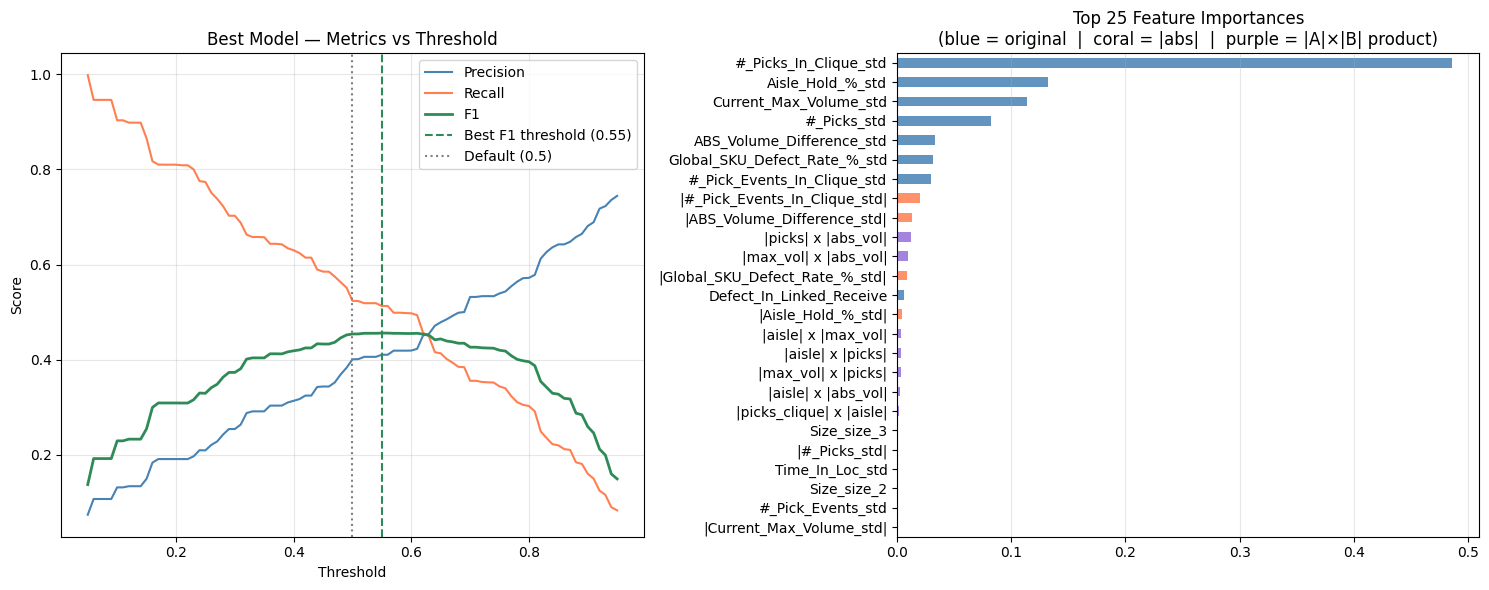

In [5]:
best_idx   = sweep_df['f1'].idxmax()
best_row   = sweep_df.iloc[best_idx]
best_dt    = records[best_idx]['_model']
best_proba = records[best_idx]['_proba']

print(f"Best: weight={best_row.weight}  max_depth={best_row.max_depth}  min_leaf={best_row.min_leaf}")
print(f"F1={best_row.f1:.4f}  P={best_row.precision:.4f}  R={best_row.recall:.4f}  AUC={best_row.auc:.4f}\n")
print(classification_report(y_test, best_dt.predict(X_test_eng), digits=3))

# ── Threshold sweep ───────────────────────────────────────────────────────────
thresholds = np.arange(0.05, 0.96, 0.01)
t_precs, t_recs, t_f1s = [], [], []
for t in thresholds:
    yp = (best_proba >= t).astype(int)
    if yp.sum() == 0:
        t_precs.append(np.nan); t_recs.append(0.0); t_f1s.append(0.0)
    else:
        t_precs.append(precision_score(y_test, yp, zero_division=0))
        t_recs.append(recall_score(y_test, yp, zero_division=0))
        t_f1s.append(f1_score(y_test, yp, zero_division=0))

t_precs = np.array(t_precs)
t_recs  = np.array(t_recs)
t_f1s   = np.array(t_f1s)
best_t_idx = int(np.nanargmax(t_f1s))
best_t     = thresholds[best_t_idx]

print(f"F1-maximising threshold: {best_t:.2f}")
print(f"  P={t_precs[best_t_idx]:.3f}  R={t_recs[best_t_idx]:.3f}  F1={t_f1s[best_t_idx]:.4f}\n")
print(classification_report(y_test, (best_proba >= best_t).astype(int), digits=3))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.plot(thresholds, t_precs, color='steelblue', label='Precision')
ax.plot(thresholds, t_recs,  color='coral',     label='Recall')
ax.plot(thresholds, t_f1s,   color='seagreen',  label='F1', linewidth=2)
ax.axvline(best_t, color='seagreen', linestyle='--',
           label=f'Best F1 threshold ({best_t:.2f})')
ax.axvline(0.5,    color='gray',     linestyle=':',  label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Best Model — Metrics vs Threshold')
ax.legend()
ax.grid(alpha=0.3)

# ── Feature importances ───────────────────────────────────────────────────────
ax2 = axes[1]
fi = (pd.Series(best_dt.feature_importances_, index=all_cols)
        .sort_values(ascending=False)
        .head(25))

# Check ' x ' first: product names now contain '|' too (e.g. "|picks_clique| x |aisle|"),
# so the product condition must be evaluated before the abs-value condition.
fi_colors = [
    'mediumpurple' if ' x ' in name else
    'coral'        if '|' in name else
    'steelblue'
    for name in fi.index
]
fi.plot(kind='barh', ax=ax2, color=fi_colors, alpha=0.85)
ax2.set_title('Top 25 Feature Importances\n'
              '(blue = original  |  coral = |abs|  |  purple = |A|×|B| product)')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Model Comparison:
                          model       f1  precision   recall      auc
Baseline DT (no weight, t=0.50) 0.377000   0.621000 0.270000 0.814000
      Eng DT (w=5x d=8, t=0.50) 0.453864   0.400529 0.523586 0.845239
      Eng DT (w=5x d=8, t=0.55) 0.455763   0.410196 0.512719 0.845239


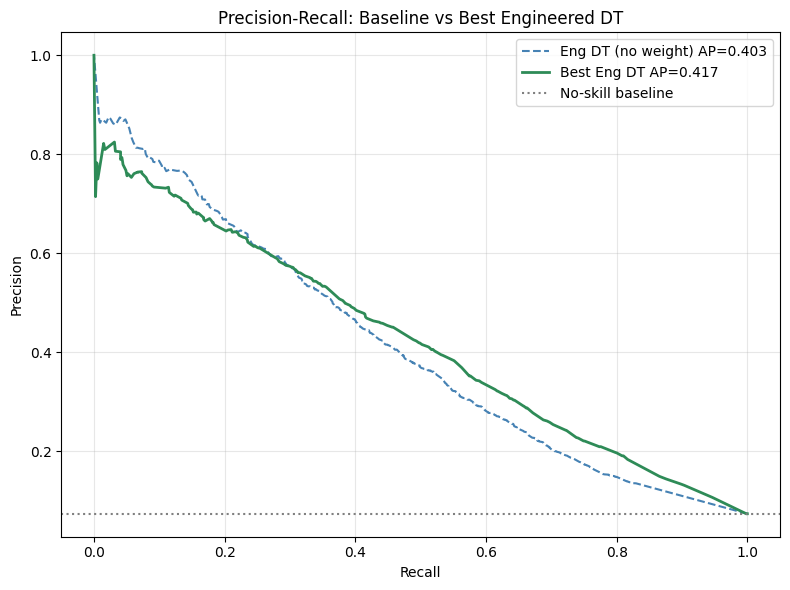

In [6]:
# ── Comparison table ──────────────────────────────────────────────────────────
comp = pd.DataFrame([
    {'model': 'Baseline DT (no weight, t=0.50)',
     'f1': 0.377, 'precision': 0.621, 'recall': 0.270, 'auc': 0.814},
    {'model': f'Eng DT (w={best_row.weight} d={best_row.max_depth}, t=0.50)',
     'f1': best_row.f1, 'precision': best_row.precision,
     'recall': best_row.recall, 'auc': best_row.auc},
    {'model': f'Eng DT (w={best_row.weight} d={best_row.max_depth}, t={best_t:.2f})',
     'f1': t_f1s[best_t_idx], 'precision': t_precs[best_t_idx],
     'recall': t_recs[best_t_idx], 'auc': best_row.auc},
])
print("Model Comparison:")
print(comp.to_string(index=False))

# ── PR curve ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Engineered no-weight model (closest to original baseline for fair comparison)
bln_matches = [r for r in records
               if r['weight'] == 'none' and r['max_depth'] == 'None'
               and r['min_leaf'] == 50]
if bln_matches:
    bln_proba = bln_matches[0]['_proba']
    p, r, _  = precision_recall_curve(y_test, bln_proba)
    ax.plot(r, p, linestyle='--', color='steelblue',
            label=f"Eng DT (no weight) AP={average_precision_score(y_test, bln_proba):.3f}")

p, r, _ = precision_recall_curve(y_test, best_proba)
ax.plot(r, p, color='seagreen', linewidth=2,
        label=f"Best Eng DT AP={average_precision_score(y_test, best_proba):.3f}")

ax.axhline(y_test.mean(), color='gray', linestyle=':', label='No-skill baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall: Baseline vs Best Engineered DT')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()